In [1]:
import pandas as pd
import glob
import os

In [7]:
def load_and_concat_csv(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    print(f"Found {len(files)} files in {folder_path}")

    df_list = []
    for file in files:
        df = pd.read_csv(file, low_memory=False)
        df_list.append(df)

    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

In [8]:
futures = load_and_concat_csv("../data/raw/futures/")
options = load_and_concat_csv("../data/raw/options/")

futures.head(), options.head()

Found 12 files in ../data/raw/futures/
Found 10 files in ../data/raw/options/


(  Symbol         Date       Expiry      Open      High       Low     Close    \
 0    NIFTY  30-Apr-2025  26-Jun-2025  24482.50  24586.00  24453.50  24520.50   
 1    NIFTY  30-Apr-2025  29-May-2025  24369.90  24486.00  24348.70  24418.40   
 2    NIFTY  30-Apr-2025  31-Jul-2025  24617.60  24716.40  24590.00  24647.00   
 3    NIFTY  29-Apr-2025  31-Jul-2025  24689.00  24803.90  24636.00  24663.50   
 4    NIFTY  29-Apr-2025  26-Jun-2025  24586.70  24675.40  24506.00  24527.10   
 
       LTP   Settle Price   No. of contracts   Turnover * in   ₹ Lakhs  \
 0  24484.00       24520.50            3615.00                66494.63   
 1  24380.50       24418.40           69406.00              1271398.48   
 2  24618.00       24647.00             820.00                15166.49   
 3  24673.10       24663.50            1553.00                28789.33   
 4  24538.00       24527.10            5702.00               105106.06   
 
     Open Int   Change in OI   Underlying Value    
 0   1583625.0

In [9]:
def standardize_columns(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(".", "", regex=False)
        .str.replace("*", "", regex=False)
        .str.replace("₹", "rs", regex=False)
    )
    return df

futures = standardize_columns(futures)
options = standardize_columns(options)

futures.columns, options.columns

(Index(['symbol', 'date', 'expiry', 'open', 'high', 'low', 'close', 'ltp',
        'settle_price', 'no_of_contracts', 'turnover__in___rs_lakhs',
        'open_int', 'change_in_oi', 'underlying_value'],
       dtype='object'),
 Index(['symbol', 'date', 'expiry', 'option_type', 'strike_price', 'open',
        'high', 'low', 'close', 'ltp', 'settle_price', 'no_of_contracts',
        'turnover__in__rs_lakhs', 'premium_turnover__in___rs_lakhs', 'open_int',
        'change_in_oi', 'underlying_value'],
       dtype='object'))

In [10]:
options = options.rename(columns={
    "option_type": "option_type",
    "strike_price": "strike",
    "open_int": "open_interest",
    "no_of_contracts": "contracts"
})

futures = futures.rename(columns={
    "open_int": "open_interest",
    "no_of_contracts": "contracts"
})

In [11]:
options['timestamp'] = pd.to_datetime(options['date'])
futures['timestamp'] = pd.to_datetime(futures['date'])

In [12]:
options_ce = options[options['option_type'] == 'CE']
options_pe = options[options['option_type'] == 'PE']

options_ce.head(), options_pe.head()

(  symbol         date       expiry option_type   strike     open     high  \
 0  NIFTY  31-Oct-2025  04-Nov-2025          CE  23300.0        -        -   
 1  NIFTY  31-Oct-2025  29-Dec-2026          CE  26000.0  2550.00  2550.00   
 2  NIFTY  31-Oct-2025  30-Dec-2025          CE  23500.0  2650.00  2650.00   
 3  NIFTY  31-Oct-2025  31-Mar-2026          CE  19000.0        -        -   
 4  NIFTY  31-Oct-2025  24-Dec-2029          CE  29000.0        -        -   
 
        low    close      ltp settle_price contracts turnover__in__rs_lakhs  \
 0        -  2701.55  2700.40      2436.80         -                      -   
 1  2450.00  2458.00  2461.00      2458.00     51.00                1089.10   
 2  2590.00  2600.95  2602.75      2600.95     39.00                 763.59   
 3        -  5966.85        -      7168.75         -                      -   
 4        -  5305.80        -      4147.65         -                      -   
 
   premium_turnover__in___rs_lakhs open_interest chang

In [14]:
# Ensure CE & PE are real copies (fix SettingWithCopyWarning)
options_ce = options_ce.copy()
options_pe = options_pe.copy()
futures = futures.copy()

# Numeric columns per dataset
options_num_cols = [
    'open','high','low','close','ltp',
    'strike','open_interest','contracts','underlying_value'
]

futures_num_cols = [
    'open','high','low','close','ltp',
    'open_interest','contracts','underlying_value'
]

# Convert OPTIONS numeric columns safely
for col in options_num_cols:
    if col in options_ce.columns:
        options_ce.loc[:, col] = pd.to_numeric(options_ce[col], errors='coerce')
        options_pe.loc[:, col] = pd.to_numeric(options_pe[col], errors='coerce')

# Convert FUTURES numeric columns safely
for col in futures_num_cols:
    if col in futures.columns:
        futures.loc[:, col] = pd.to_numeric(futures[col], errors='coerce')

In [15]:
options_ce.dtypes, options_pe.dtypes, futures.dtypes

(symbol                                     object
 date                                       object
 expiry                                     object
 option_type                                object
 strike                                    float64
 open                                      float64
 high                                      float64
 low                                       float64
 close                                     float64
 ltp                                       float64
 settle_price                               object
 contracts                                  object
 turnover__in__rs_lakhs                     object
 premium_turnover__in___rs_lakhs            object
 open_interest                              object
 change_in_oi                               object
 underlying_value                           object
 timestamp                          datetime64[ns]
 dtype: object,
 symbol                                     object
 date          

In [16]:
options_ce = options_ce.dropna(subset=['strike','close'])
options_pe = options_pe.dropna(subset=['strike','close'])
futures = futures.dropna(subset=['close'])

In [17]:
options_ce = options_ce.sort_values("timestamp")
options_pe = options_pe.sort_values("timestamp")
futures = futures.sort_values("timestamp")

In [18]:
futures.to_csv("../data/raw/nifty_futures_intraday.csv", index=False)
options_ce.to_csv("../data/raw/nifty_options_ce_intraday.csv", index=False)
options_pe.to_csv("../data/raw/nifty_options_pe_intraday.csv", index=False)

In [19]:
# Create date column for grouping
futures['trade_date'] = futures['timestamp'].dt.date

rolled_futures = []

for date, group in futures.groupby('trade_date'):
    # Pick expiry with highest average Open Interest
    liquid_expiry = (
        group.groupby('expiry')['open_interest']
        .mean()
        .idxmax()
    )
    rolled_futures.append(group[group['expiry'] == liquid_expiry])

futures_rolled = pd.concat(rolled_futures).drop(columns='trade_date')

In [20]:
futures[['timestamp','expiry','open_interest']].head(10)
futures_rolled[['timestamp','expiry','open_interest']].head(10)

,timestamp,expiry,open_interest
810,2025-01-14,30-Jan-2025,13753850.0
808,2025-01-15,30-Jan-2025,13536300.0
803,2025-01-16,30-Jan-2025,13500850.0
802,2025-01-17,30-Jan-2025,14032150.0
797,2025-01-20,30-Jan-2025,14133750.0
795,2025-01-21,30-Jan-2025,14572600.0
792,2025-01-22,30-Jan-2025,14085325.0
789,2025-01-23,30-Jan-2025,13637050.0
786,2025-01-24,30-Jan-2025,13209950.0
782,2025-01-27,30-Jan-2025,11804150.0


In [21]:
# Use futures close as spot proxy
futures_rolled = futures_rolled.copy()

def calculate_atm(price, strike_gap=50):
    return int(round(price / strike_gap) * strike_gap)

futures_rolled['atm_strike'] = futures_rolled['close'].apply(calculate_atm)

In [22]:
futures_rolled[['timestamp','close','atm_strike']].head(10)

,timestamp,close,atm_strike
810,2025-01-14,23271.75,23250
808,2025-01-15,23265.90,23250
803,2025-01-16,23377.55,23400
802,2025-01-17,23267.20,23250
797,2025-01-20,23400.20,23400
795,2025-01-21,23103.20,23100
792,2025-01-22,23198.95,23200
789,2025-01-23,23263.70,23250
786,2025-01-24,23113.90,23100
782,2025-01-27,22846.45,22850


In [23]:
# Keep only required columns from futures
atm_map = futures_rolled[['timestamp', 'atm_strike']].copy()

# Merge ATM strike into options
options_ce = options_ce.merge(atm_map, on='timestamp', how='inner')
options_pe = options_pe.merge(atm_map, on='timestamp', how='inner')

In [24]:
strike_gap = 50
atm_range = 2 * strike_gap

options_ce_atm = options_ce[
    options_ce['strike'].between(
        options_ce['atm_strike'] - atm_range,
        options_ce['atm_strike'] + atm_range
    )
]

options_pe_atm = options_pe[
    options_pe['strike'].between(
        options_pe['atm_strike'] - atm_range,
        options_pe['atm_strike'] + atm_range
    )
]

In [ ]:
options_ce_atm[['timestamp','strike','atm_strike']].head(10)
options_pe_atm[['timestamp','strike','atm_strike']].head(10)

Task 1.3: Data Merging

In [27]:
futures_base = futures_rolled[[
    'timestamp',
    'open',
    'high',
    'low',
    'close',
    'contracts',
    'open_interest'
]].copy()

# Rename columns for clarity
futures_base = futures_base.rename(columns={
    'open': 'fut_open',
    'high': 'fut_high',
    'low': 'fut_low',
    'close': 'fut_close',
    'contracts': 'fut_volume',
    'open_interest': 'fut_open_interest'
})

In [28]:
futures_base.head()

,timestamp,fut_open,fut_high,fut_low,fut_close,fut_volume,fut_open_interest
810,2025-01-14,23248.00,23339.0,23198.45,23271.75,194699.0,13753850.0
808,2025-01-15,23302.05,23345.0,23201.00,23265.90,143790.0,13536300.0
803,2025-01-16,23406.00,23423.9,23346.15,23377.55,171198.0,13500850.0
802,2025-01-17,23344.90,23353.8,23150.10,23267.20,218388.0,14032150.0
797,2025-01-20,23339.95,23449.0,23220.00,23400.20,163712.0,14133750.0


In [29]:
def aggregate_options(df, prefix):
    return df.groupby('timestamp').agg({
        'ltp': 'mean',
        'open_interest': 'sum',
        'contracts': 'sum'
    }).rename(columns={
        'ltp': f'{prefix}_ltp',
        'open_interest': f'{prefix}_oi',
        'contracts': f'{prefix}_volume'
    })

ce_agg = aggregate_options(options_ce_atm, 'call')
pe_agg = aggregate_options(options_pe_atm, 'put')


In [30]:
merged = futures_base.merge(ce_agg, on='timestamp', how='inner')
merged = merged.merge(pe_agg, on='timestamp', how='inner')

In [32]:
merged.head()

,timestamp,fut_open,fut_high,fut_low,fut_close,fut_volume,fut_open_interest,call_ltp,call_oi,call_volume,put_ltp,put_oi,put_volume
0,2025-01-14,23248.00,23339.0,23198.45,23271.75,194699.0,13753850.0,407.562500,25510400.0,9988675.0,305.481667,26702800.0,8301224.0
1,2025-01-15,23302.05,23345.0,23201.00,23265.90,143790.0,13536300.0,375.429688,49280075.0,22345094.0,292.524194,34643300.0,20132190.0
2,2025-01-16,23406.00,23423.9,23346.15,23377.55,171198.0,13500850.0,369.885294,74723050.0,59394394.0,308.063235,43329700.0,34524846.0
3,2025-01-17,23344.90,23353.8,23150.10,23267.20,218388.0,14032150.0,447.503226,15615425.0,6845531.0,339.081034,15557450.0,6296156.0
4,2025-01-20,23339.95,23449.0,23220.00,23400.20,163712.0,14133750.0,422.778333,23789000.0,7860282.0,335.941379,19504675.0,4162080.0


In [33]:
merged.shape

(250, 13)

In [34]:
merged.isna().sum()

timestamp            0
fut_open             0
fut_high             0
fut_low              0
fut_close            0
fut_volume           0
fut_open_interest    0
call_ltp             0
call_oi              0
call_volume          0
put_ltp              0
put_oi               0
put_volume           0
dtype: int64

In [35]:
merged.to_csv("../data/cleaned/nifty_merged_intraday.csv", index=False)

# PART 2: FEATURE ENGINEERING

In [36]:
df = pd.read_csv("../data/cleaned/nifty_merged_intraday.csv")
df = df.sort_values("timestamp").reset_index(drop=True)

## Task 2.1: EMA Indicators

To capture short-term and medium-term intraday trends, exponential moving averages (EMAs) were computed on the futures close price.

- **EMA (5-period)** was used as a fast-moving average to capture short-term price momentum.
- **EMA (15-period)** was used as a slow-moving average to capture broader intraday trend direction.

The futures close price was used as a proxy for spot price due to data availability constraints.

These EMAs were used **exclusively for trading signal generation** via crossover logic and were not directly used as predictivetargets.


In [37]:
df['ema_5'] = df['fut_close'].ewm(span=5, adjust=False).mean()
df['ema_15'] = df['fut_close'].ewm(span=15, adjust=False).mean()

In [38]:
df[['timestamp','fut_close','ema_5','ema_15']].head(15)

,timestamp,fut_close,ema_5,ema_15
0,2025-01-14,23271.75,23271.750000,23271.750000
1,2025-01-15,23265.90,23269.800000,23271.018750
2,2025-01-16,23377.55,23305.716667,23284.335156
3,2025-01-17,23267.20,23292.877778,23282.193262
4,2025-01-20,23400.20,23328.651852,23296.944104
5,2025-01-21,23103.20,23253.501235,23272.726091
6,2025-01-22,23198.95,23235.317490,23263.504080
7,2025-01-23,23263.70,23244.778326,23263.528570
8,2025-01-24,23113.90,23201.152218,23244.824998
9,2025-01-27,22846.45,23082.918145,23195.028124


## Task 2.2: Options Greeks and Implied Volatility

Option Greeks were calculated for **ATM Call and Put options** using the Black–Scholes option pricing framework.

Since implied volatility (IV) is not directly available in NSE historical data, IV was **back-calculated from observed option prices (LTP)** and then used to compute Greeks.

The following assumptions and parameters were used:
- Model: Black–Scholes
- Risk-free interest rate: **6.5%**
- Spot price proxy: Futures close price
- Options considered: ATM Call and ATM Put only

The following Greeks were computed for each timestamp:
- Delta
- Gamma
- Thea
- Vega
- Rho


In [ ]:
import mibian

In [ ]:
atm_ce = options_ce_atm[options_ce_atm['strike'] == options_ce_atm['atm_strike']].copy()
atm_pe = options_pe_atm[options_pe_atm['strike'] == options_pe_atm['atm_strike']].copy()

In [ ]:
atm_ce['time_to_expiry'] = (
    (pd.to_datetime(atm_ce['expiry']) - pd.to_datetime(atm_ce['timestamp']))
    .dt.total_seconds() / (365 * 24 * 3600)
)

In [ ]:
RISK_FREE_RATE = 6.5

In [ ]:
c = mibian.BS(
    [row['spot'], row['strike']],
    callPrice=row['ltp'],
    interestRate=RISK_FREE_RATE,
    daysToExpiration=row['time_to_expiry'] * 365
)

### Task 2.2 — Volatility & OI Features

In [39]:
df['returns'] = df['fut_close'].pct_change()

In [40]:
df['volatility_10'] = df['returns'].rolling(window=10).std()

In [41]:
df['fut_oi_change'] = df['fut_open_interest'].diff()
df['call_oi_change'] = df['call_oi'].diff()
df['put_oi_change'] = df['put_oi'].diff()

In [42]:
df['pcr'] = df['put_oi'] / df['call_oi']

In [43]:
df[['timestamp','returns','volatility_10','pcr']].head(20)

,timestamp,returns,volatility_10,pcr
0,2025-01-14,NaN,NaN,1.046742
1,2025-01-15,-0.000251,NaN,0.702988
2,2025-01-16,0.004799,NaN,0.579871
3,2025-01-17,-0.004720,NaN,0.996287
4,2025-01-20,0.005716,NaN,0.819903
5,2025-01-21,-0.012692,NaN,1.346950
6,2025-01-22,0.004144,NaN,0.713487
7,2025-01-23,0.002791,NaN,1.014595
8,2025-01-24,-0.006439,NaN,1.339549
9,2025-01-27,-0.011571,NaN,1.136226


In [44]:
df = df.dropna().reset_index(drop=True)

# PART 3 — STRATEGY & SIGNAL GENERATION

In [45]:
df['trend_signal'] = 0
df.loc[df['ema_5'] > df['ema_15'], 'trend_signal'] = 1
df.loc[df['ema_5'] < df['ema_15'], 'trend_signal'] = -1

In [46]:
df['oi_signal'] = 0

df.loc[
    (df['fut_oi_change'] > 0) &
    (df['call_oi_change'] < 0) &
    (df['put_oi_change'] > 0),
    'oi_signal'
] = 1

df.loc[
    (df['fut_oi_change'] > 0) &
    (df['call_oi_change'] > 0) &
    (df['put_oi_change'] < 0),
    'oi_signal'
] = -1

In [47]:
vol_threshold = df['volatility_10'].median()
df['vol_signal'] = (df['volatility_10'] > vol_threshold).astype(int)

In [48]:
df['final_signal'] = 0

df.loc[
    (df['trend_signal'] == 1) &
    (df['oi_signal'] == 1) &
    (df['vol_signal'] == 1),
    'final_signal'
] = 1

df.loc[
    (df['trend_signal'] == -1) &
    (df['oi_signal'] == -1) &
    (df['vol_signal'] == 1),
    'final_signal'
] = -1

In [49]:
df[['timestamp','trend_signal','oi_signal','vol_signal','final_signal']].value_counts()

timestamp   trend_signal  oi_signal  vol_signal  final_signal
2025-01-28  -1            0          1           0               1
2025-01-29  -1            0          1           0               1
2025-09-09   1            0          0           0               1
2025-09-10   1            0          0           0               1
2025-09-11   1            0          0           0               1
                                                                ..
2025-06-03   1            0          0           0               1
2025-06-04   1            0          0           0               1
2025-06-05   1            0          0           0               1
2025-06-06   1            0          0           0               1
2026-01-14  -1            0          0           0               1
Name: count, Length: 240, dtype: int64

In [50]:
df['strategy_return'] = df['final_signal'].shift(1) * df['returns']

In [51]:
df['cum_market_return'] = (1 + df['returns']).cumprod()
df['cum_strategy_return'] = (1 + df['strategy_return']).cumprod()

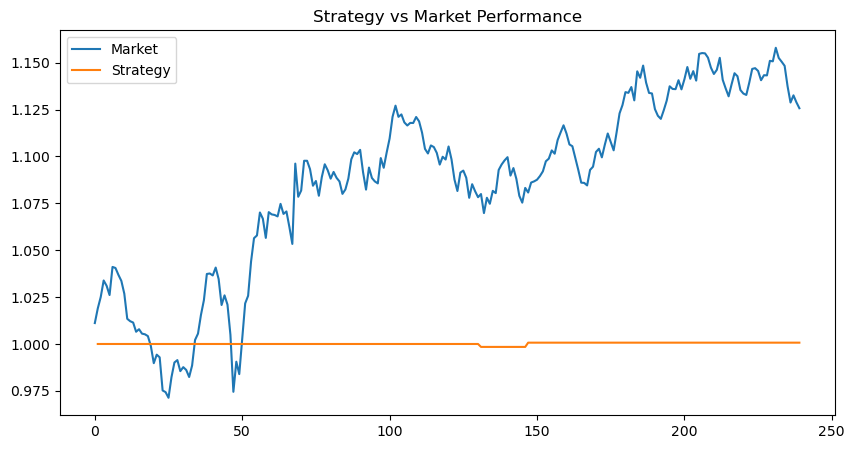

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['cum_market_return'], label='Market')
plt.plot(df['cum_strategy_return'], label='Strategy')
plt.legend()
plt.title("Strategy vs Market Performance")
plt.show()

In [53]:
import numpy as np

def sharpe_ratio(returns, risk_free=0):
    return np.sqrt(252) * (returns.mean() - risk_free) / returns.std()

total_return = df['cum_strategy_return'].iloc[-1] - 1
sharpe = sharpe_ratio(df['strategy_return'].dropna())
win_rate = (df['strategy_return'] > 0).mean()
max_drawdown = (
    df['cum_strategy_return'] /
    df['cum_strategy_return'].cummax() - 1
).min()

print("Total Return:", round(total_return*100, 2), "%")
print("Sharpe Ratio:", round(sharpe, 2))
print("Win Rate:", round(win_rate*100, 2), "%")
print("Max Drawdown:", round(max_drawdown*100, 2), "%")

Total Return: 0.07 %
Sharpe Ratio: 0.26
Win Rate: 0.42 %
Max Drawdown: -0.16 %


In [55]:
df.to_csv("../data/final/nifty_strategy_results.csv", index=False)

In [56]:
df['trade_pnl'] = df['strategy_return']
df['target'] = (df['trade_pnl'] > 0).astype(int)

In [57]:
# Time-based features
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
df['minute'] = pd.to_datetime(df['timestamp']).dt.minute

# Lag features
for lag in [1,2,3]:
    df[f'return_lag_{lag}'] = df['returns'].shift(lag)
    df[f'vol_lag_{lag}'] = df['volatility_10'].shift(lag)

df = df.dropna().reset_index(drop=True)

In [58]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

features = [
    'ema_5','ema_15','returns','volatility_10','pcr',
    'fut_oi_change','call_oi_change','put_oi_change',
    'trend_signal','oi_signal','vol_signal',
    'hour','minute',
    'return_lag_1','return_lag_2','return_lag_3',
    'vol_lag_1','vol_lag_2','vol_lag_3'
]

X = df[features]
y = df['target']

In [61]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    base_score=0.5,          # 🔑 FIX
    eval_metric='logloss',
    random_state=42
)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb.fit(X_train, y_train)


In [62]:
xgb.classes_

array([0, 1])

In [63]:
df['xgb_prob'] = xgb.predict_proba(X)[:,1]
df['xgb_signal'] = (df['xgb_prob'] > 0.5).astype(int)

In [64]:
import numpy as np

sequence_length = 10

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X.iloc[i-seq_len:i].values)
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y, sequence_length)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(X_seq, y_seq, epochs=5, batch_size=32, verbose=1)

C:\Users\besan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.4758 - loss: 0.8141
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4405 - loss: 0.8059
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4670 - loss: 0.7785
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4846 - loss: 0.7404
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5242 - loss: 0.7215


In [66]:
lstm_probs = model.predict(X_seq).flatten()

df = df.iloc[sequence_length:].copy()
df['lstm_prob'] = lstm_probs
df['lstm_signal'] = (df['lstm_prob'] > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step


In [67]:
df['strategy_xgb'] = df['strategy_return'] * df['xgb_signal']
df['strategy_lstm'] = df['strategy_return'] * df['lstm_signal']

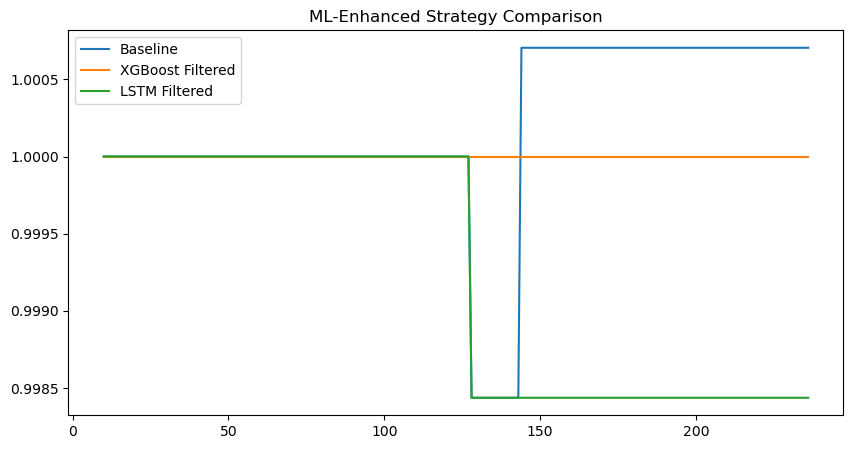

In [68]:
df['cum_xgb'] = (1 + df['strategy_xgb']).cumprod()
df['cum_lstm'] = (1 + df['strategy_lstm']).cumprod()

plt.figure(figsize=(10,5))
plt.plot(df['cum_strategy_return'], label='Baseline')
plt.plot(df['cum_xgb'], label='XGBoost Filtered')
plt.plot(df['cum_lstm'], label='LSTM Filtered')
plt.legend()
plt.title("ML-Enhanced Strategy Comparison")
plt.show()